In [17]:
import pandas as pd

# Load the first sheet of the Excel file
df = pd.read_excel('weather_data.xlsx')
print(df.info())
print(df.head())
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1000 non-null   object 
 1   PRCP    1000 non-null   float64
 2   TMAX    1000 non-null   float64
 3   TMIN    1000 non-null   float64
 4   RAIN    1000 non-null   float64
dtypes: float64(4), object(1)
memory usage: 39.2+ KB
None
         Date  PRCP  TMAX  TMIN  RAIN
0  1969-01-14  10.5   5.5  -3.6  10.5
1  1969-01-19   0.0   0.3  -1.7   0.0
2  1969-02-07   0.0   4.4   1.0   0.0
3  1969-02-25   0.0   0.1  -5.1   0.0
4  1969-03-12   0.0  12.1   3.3   0.0


In [9]:
# Check total missing entries per attribute
print(df.isnull().sum())

# Option A: Drop missing instances
df_clean = df.dropna()


PRCP    0
TMAX    0
TMIN    0
RAIN    0
dtype: int64


C:\Users\hooma\AppData\Local\Temp\ipykernel_24812\2495070926.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_weather = df[['PRCP', 'TMAX', 'TMIN', 'RAIN']].resample('M').mean()


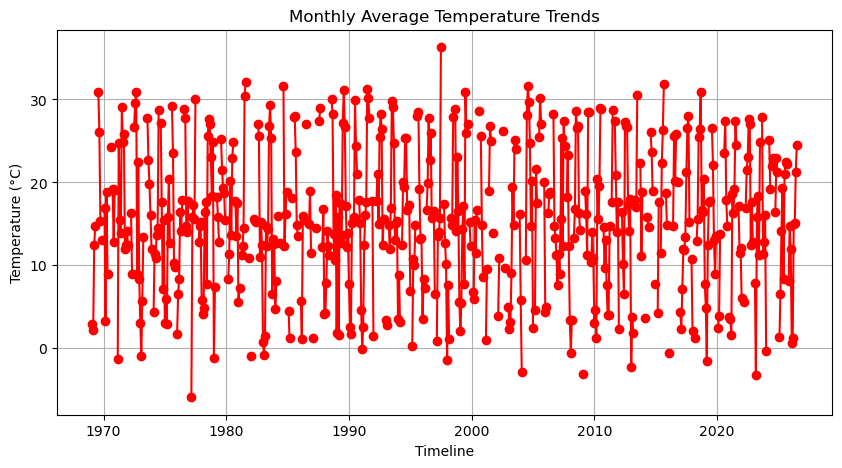

In [14]:
import matplotlib.pyplot as plt
# Resample data to calculate monthly averages
monthly_weather = df[['PRCP', 'TMAX', 'TMIN', 'RAIN']].resample('M').mean()
plt.figure(figsize=(10, 5))
plt.plot(monthly_weather.index, monthly_weather['TMAX'], color='red', marker='o')
plt.title('Monthly Average Maximum Temperature Trends')
plt.xlabel('Timeline')
plt.ylabel('Temperature (°C)')
plt.grid(True)


C:\Users\hooma\AppData\Local\Temp\ipykernel_24812\1716129022.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_weather = df[['PRCP', 'TMAX', 'TMIN', 'RAIN']].resample('M').mean()


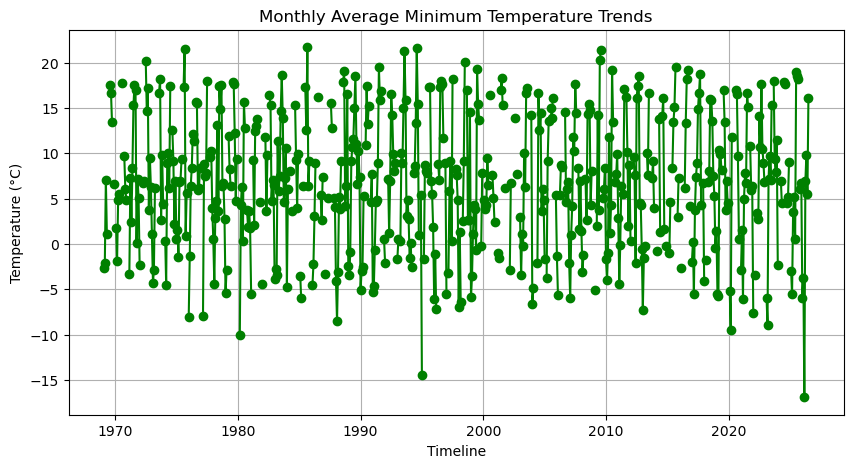

In [19]:
import matplotlib.pyplot as plt
# Resample data to calculate monthly averages
monthly_weather = df[['PRCP', 'TMAX', 'TMIN', 'RAIN']].resample('M').mean()
plt.figure(figsize=(10, 5))
plt.plot(monthly_weather.index, monthly_weather['TMIN'], color='green', marker='o')
plt.title('Monthly Average Minimum Temperature Trends')
plt.xlabel('Timeline')
plt.ylabel('Temperature (°C)')
plt.grid(True)


C:\Users\hooma\AppData\Local\Temp\ipykernel_24812\74825065.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_weather = df[['PRCP', 'TMAX', 'TMIN', 'RAIN']].resample('M').mean()


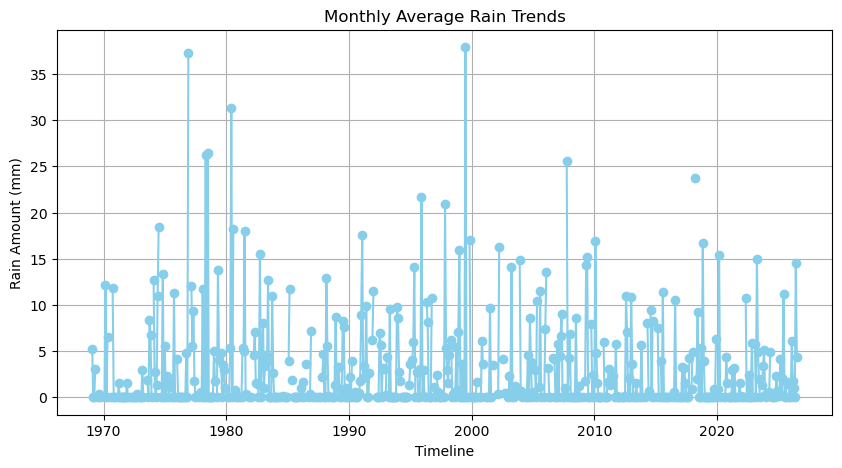

In [21]:
import matplotlib.pyplot as plt
# Resample data to calculate monthly averages
monthly_weather = df[['PRCP', 'TMAX', 'TMIN', 'RAIN']].resample('M').mean()
plt.figure(figsize=(10, 5))
plt.plot(monthly_weather.index, monthly_weather['PRCP'], color='skyblue', marker='o')
plt.title('Monthly Average Rain Trends')
plt.xlabel('Timeline')
plt.ylabel('Rain Amount (mm)')
plt.grid(True)


WEATHER DATA ANALYSIS REPORT

Date range : 1969-01-14  →  2026-06-04
Records    : 1,000
Years      : 58

── Summary Statistics ──────────────────────────────────────
          PRCP     TMAX     TMIN     RAIN  TempRange
count  1000.00  1000.00  1000.00  1000.00    1000.00
mean      2.80    15.66     6.88     2.80       8.78
std       6.20     8.99     7.60     6.20       5.39
min       0.00    -5.90   -16.90     0.00       2.00
25%       0.00     9.40     1.70     0.00       4.10
50%       0.00    15.40     6.80     0.00       8.30
75%       2.22    22.70    12.92     2.22      12.50
max      51.20    39.30    24.00    51.20      28.60

── Seasonal Averages ───────────────────────────────────────
        TMAX_mean  TMIN_mean  PRCP_mean
Season                                 
Autumn      14.95       6.09       3.02
Spring      15.39       6.88       3.10
Summer      26.92      16.27       1.92
Winter       3.95      -2.90       3.18

── Extreme Events ────────────────────────────────────

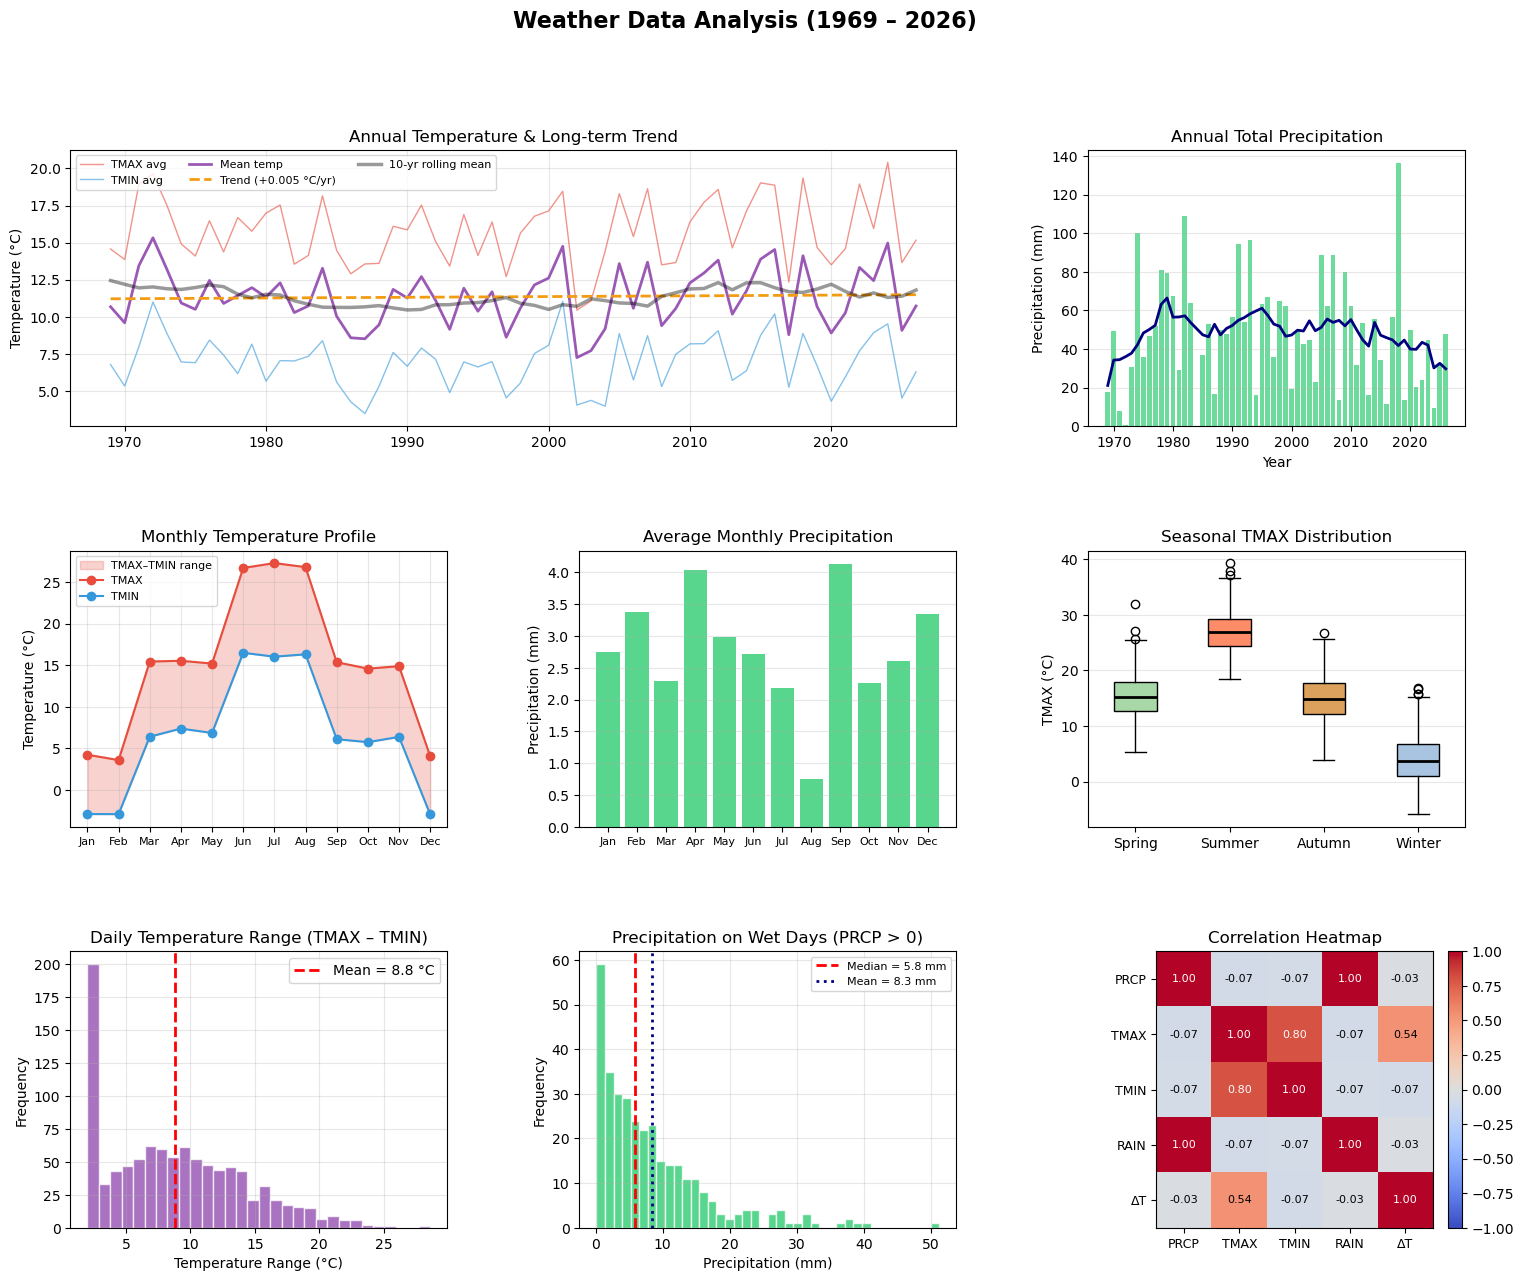

In [16]:
"""
Weather Data Analysis
=====================
Analyzes historical weather data (1969–2026) with:
  - Summary statistics
  - Temperature trends (annual averages + rolling mean)
  - Precipitation patterns by month and year
  - Seasonal breakdown
  - Extreme event detection
  - Long-term climate trend (linear regression)
  - Correlation heatmap

Columns: Date, PRCP (precipitation mm), TMAX (°C), TMIN (°C), RAIN (mm)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import warnings

warnings.filterwarnings("ignore")

# ── 1. Load & clean ──────────────────────────────────────────────────────────
df = pd.read_excel("weather_data.xlsx")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

df["Year"]  = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Season"] = df["Month"].map({
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Autumn", 10: "Autumn", 11: "Autumn",
})
df["TempRange"] = df["TMAX"] - df["TMIN"]

print("=" * 60)
print("WEATHER DATA ANALYSIS REPORT")
print("=" * 60)
print(f"\nDate range : {df['Date'].min().date()}  →  {df['Date'].max().date()}")
print(f"Records    : {len(df):,}")
print(f"Years      : {df['Year'].nunique()}")
print("\n── Summary Statistics ──────────────────────────────────────")
print(df[["PRCP", "TMAX", "TMIN", "RAIN", "TempRange"]].describe().round(2).to_string())

# ── 2. Annual aggregates ──────────────────────────────────────────────────────
annual = df.groupby("Year").agg(
    TMAX_mean  = ("TMAX",  "mean"),
    TMIN_mean  = ("TMIN",  "mean"),
    PRCP_total = ("PRCP",  "sum"),
    PRCP_days  = ("PRCP",  lambda x: (x > 0).sum()),
    Records    = ("Date",  "count"),
).reset_index()
annual["Tmean"] = (annual["TMAX_mean"] + annual["TMIN_mean"]) / 2

# ── 3. Monthly averages ───────────────────────────────────────────────────────
MONTH_NAMES = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]
monthly = df.groupby("Month").agg(
    TMAX_mean  = ("TMAX",  "mean"),
    TMIN_mean  = ("TMIN",  "mean"),
    PRCP_mean  = ("PRCP",  "mean"),
    PRCP_total = ("PRCP",  "sum"),
).reset_index()

# ── 4. Seasonal summary ───────────────────────────────────────────────────────
seasonal = df.groupby("Season").agg(
    TMAX_mean  = ("TMAX",  "mean"),
    TMIN_mean  = ("TMIN",  "mean"),
    PRCP_mean  = ("PRCP",  "mean"),
).round(2)
print("\n── Seasonal Averages ───────────────────────────────────────")
print(seasonal.to_string())

# ── 5. Extreme events ─────────────────────────────────────────────────────────
hot_days   = df[df["TMAX"] >= 35]
cold_days  = df[df["TMIN"] <= -10]
heavy_rain = df[df["PRCP"] >= 30]

print(f"\n── Extreme Events ──────────────────────────────────────────")
print(f"Hot days   (TMAX ≥ 35 °C) : {len(hot_days):>4}  |  hottest: {df['TMAX'].max():.1f} °C on {df.loc[df['TMAX'].idxmax(),'Date'].date()}")
print(f"Cold days  (TMIN ≤ -10 °C): {len(cold_days):>4}  |  coldest: {df['TMIN'].min():.1f} °C on {df.loc[df['TMIN'].idxmin(),'Date'].date()}")
print(f"Heavy rain (PRCP ≥ 30 mm) : {len(heavy_rain):>4}  |  wettest: {df['PRCP'].max():.1f} mm on {df.loc[df['PRCP'].idxmax(),'Date'].date()}")

# ── 6. Linear trend on annual mean temperature ────────────────────────────────
slope, intercept, r, p, _ = stats.linregress(annual["Year"], annual["Tmean"])
print(f"\n── Long-term Temperature Trend ─────────────────────────────")
print(f"Slope  : {slope:+.4f} °C / year")
print(f"Over {annual['Year'].max()-annual['Year'].min()} years: {slope*(annual['Year'].max()-annual['Year'].min()):+.2f} °C total")
print(f"R²     : {r**2:.3f}   p-value: {p:.4f}")

# ── 7. Plots ──────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 14))
fig.suptitle("Weather Data Analysis (1969 – 2026)", fontsize=16, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

COLORS = {
    "tmax": "#e74c3c", "tmin": "#3498db", "tmean": "#9b59b6",
    "prcp": "#2ecc71", "trend": "#f39c12",
}

# 7a. Annual mean temperature + trend
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(annual["Year"], annual["TMAX_mean"], color=COLORS["tmax"], alpha=0.6, linewidth=1, label="TMAX avg")
ax1.plot(annual["Year"], annual["TMIN_mean"], color=COLORS["tmin"], alpha=0.6, linewidth=1, label="TMIN avg")
ax1.plot(annual["Year"], annual["Tmean"],     color=COLORS["tmean"], linewidth=2, label="Mean temp")
trend_line = slope * annual["Year"] + intercept
ax1.plot(annual["Year"], trend_line, "--", color=COLORS["trend"], linewidth=2,
         label=f"Trend ({slope:+.3f} °C/yr)")
# Rolling 10-yr mean
roll = annual["Tmean"].rolling(10, center=True, min_periods=5).mean()
ax1.plot(annual["Year"], roll, color="black", linewidth=2.5, alpha=0.4, label="10-yr rolling mean")
ax1.set_title("Annual Temperature & Long-term Trend")
ax1.set_ylabel("Temperature (°C)")
ax1.legend(fontsize=8, ncol=3)
ax1.grid(alpha=0.3)

# 7b. Annual total precipitation
ax2 = fig.add_subplot(gs[0, 2])
ax2.bar(annual["Year"], annual["PRCP_total"], color=COLORS["prcp"], alpha=0.7)
ax2.plot(annual["Year"],
         annual["PRCP_total"].rolling(10, center=True, min_periods=5).mean(),
         color="navy", linewidth=2)
ax2.set_title("Annual Total Precipitation")
ax2.set_ylabel("Precipitation (mm)")
ax2.set_xlabel("Year")
ax2.grid(alpha=0.3, axis="y")

# 7c. Monthly temperature profile
ax3 = fig.add_subplot(gs[1, 0])
x = np.arange(1, 13)
ax3.fill_between(x, monthly["TMIN_mean"], monthly["TMAX_mean"],
                 color=COLORS["tmax"], alpha=0.25, label="TMAX–TMIN range")
ax3.plot(x, monthly["TMAX_mean"], "o-", color=COLORS["tmax"], label="TMAX")
ax3.plot(x, monthly["TMIN_mean"], "o-", color=COLORS["tmin"], label="TMIN")
ax3.set_xticks(x); ax3.set_xticklabels(MONTH_NAMES, fontsize=8)
ax3.set_title("Monthly Temperature Profile")
ax3.set_ylabel("Temperature (°C)")
ax3.legend(fontsize=8); ax3.grid(alpha=0.3)

# 7d. Monthly precipitation
ax4 = fig.add_subplot(gs[1, 1])
ax4.bar(x, monthly["PRCP_mean"], color=COLORS["prcp"], alpha=0.8)
ax4.set_xticks(x); ax4.set_xticklabels(MONTH_NAMES, fontsize=8)
ax4.set_title("Average Monthly Precipitation")
ax4.set_ylabel("Precipitation (mm)")
ax4.grid(alpha=0.3, axis="y")

# 7e. Seasonal box plots – TMAX
ax5 = fig.add_subplot(gs[1, 2])
season_order = ["Spring", "Summer", "Autumn", "Winter"]
season_data  = [df[df["Season"] == s]["TMAX"].values for s in season_order]
bp = ax5.boxplot(season_data, labels=season_order, patch_artist=True,
                 medianprops=dict(color="black", linewidth=2))
colors_box = ["#a8d8a8", "#ff8c69", "#dda15e", "#a8c4e0"]
for patch, c in zip(bp["boxes"], colors_box):
    patch.set_facecolor(c)
ax5.set_title("Seasonal TMAX Distribution")
ax5.set_ylabel("TMAX (°C)")
ax5.grid(alpha=0.3, axis="y")

# 7f. Temperature range histogram
ax6 = fig.add_subplot(gs[2, 0])
ax6.hist(df["TempRange"], bins=30, color="#8e44ad", alpha=0.75, edgecolor="white")
ax6.axvline(df["TempRange"].mean(), color="red", linewidth=2, linestyle="--",
            label=f"Mean = {df['TempRange'].mean():.1f} °C")
ax6.set_title("Daily Temperature Range (TMAX – TMIN)")
ax6.set_xlabel("Temperature Range (°C)")
ax6.set_ylabel("Frequency")
ax6.legend(); ax6.grid(alpha=0.3)

# 7g. Precipitation distribution (non-zero)
ax7 = fig.add_subplot(gs[2, 1])
wet = df[df["PRCP"] > 0]["PRCP"]
ax7.hist(wet, bins=40, color=COLORS["prcp"], alpha=0.8, edgecolor="white")
ax7.axvline(wet.median(), color="red",   linewidth=2, linestyle="--",
            label=f"Median = {wet.median():.1f} mm")
ax7.axvline(wet.mean(),   color="navy",  linewidth=2, linestyle=":",
            label=f"Mean = {wet.mean():.1f} mm")
ax7.set_title("Precipitation on Wet Days (PRCP > 0)")
ax7.set_xlabel("Precipitation (mm)")
ax7.set_ylabel("Frequency")
ax7.legend(fontsize=8); ax7.grid(alpha=0.3)

# 7h. Correlation heatmap
ax8 = fig.add_subplot(gs[2, 2])
corr = df[["PRCP", "TMAX", "TMIN", "RAIN", "TempRange"]].corr()
im = ax8.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
labels = ["PRCP", "TMAX", "TMIN", "RAIN", "ΔT"]
ax8.set_xticks(range(len(labels))); ax8.set_xticklabels(labels, fontsize=9)
ax8.set_yticks(range(len(labels))); ax8.set_yticklabels(labels, fontsize=9)
for i in range(len(labels)):
    for j in range(len(labels)):
        ax8.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center",
                 fontsize=8, color="black" if abs(corr.iloc[i, j]) < 0.7 else "white")
ax8.set_title("Correlation Heatmap")
plt.colorbar(im, ax=ax8, fraction=0.046, pad=0.04)

plt.savefig("weather_analysis.png", dpi=150, bbox_inches="tight")
print("\nChart saved → weather_analysis.png")
plt.show()
